This notebook serves as a sanity check as to what second-order lensing transformations do to the waveform when $R_{orbit}$ gets large.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)


import gwfast.lensing_utils as lutils

In [7]:
# Define a benchmark event
n = 300
shape = (n,)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'Phicoal':np.full(shape, 2), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.3)
}

# Vary R_orbit
events['R_orbit'] = np.linspace(20, 500, n)

events = {key: val.astype(np.float64) for key, val in events.items()}

Text(0, 0.5, '$\\Delta\\cos\\iota$')

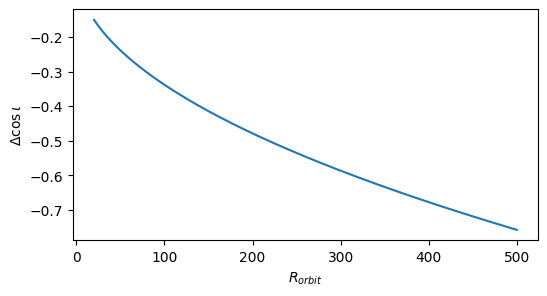

In [8]:
# Compute second order lensing corrections
# For simplicity, M_lz is used in place of M_lens
theta_E = lutils.einstein_radius(events['M_lz'], events['dL'], events['R_orbit'])
phi_L = lutils.get_phi_L(events['iota'], events['R_orbit'], events['src_pos'], theta_E, events['dL'], events['M_lz'])
delta_cos_iota, delta_cos_phi, delta_cos_psi, z_orbit, z_grav = \
    lutils.get_lensing_induced_cosine_shifts(events['iota'], phi_L, events['R_orbit'], events['Phicoal'], events['psi'])

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(events['R_orbit'], delta_cos_iota)
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$\Delta\cos\iota$')

Uh-oh this is not good! Cosine shifts should tend to zero!